In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from aggregation import get_country_interpolators

In [ ]:
def convert_nominal_2023_to_nominal_survey_year(amt, country):
    inflation_adjustment = {2018: 0.83, 2019: 0.84}
    df= pd.read_csv('currency_conversion.csv')
    survey_year = df[df['country'] == country]["survey_year"].values[0]
    amt = amt * inflation_adjustment[survey_year]
    return amt



def plot_bar_chart_policy_amt_as_percent_of_gdp(countries, method, geo_extrapolation, save_as):
    dic = get_country_interpolators(countries, method, geo_extrapolation)

    amts = [] # nominal 2023 USD amts
    for country in countries:
        amt = dic[country]['gap_to_cost_interpolator'](1.).item()
        amts.append(amt)
        print(country, amt)

    print('total', sum(amts))
    amts_survey_year = [convert_nominal_2023_to_nominal_survey_year(amt, country) for amt, country in zip(amts, countries)]

    df = pd.read_csv('currency_conversion.csv')
    gdp = df[df['country'].isin(countries)][['country', 'GDP_billions_survey_year']].set_index('country').to_dict()['GDP_billions_survey_year']
    gdp = {country: gdp[country] for country in countries}
    amts_as_percent_of_gdp = [amt * 100 / gdp[country] for amt, country in zip(amts_survey_year, countries)]

    govt_revenue_percentage = df[df['country'].isin(countries)][['country', 'govt_revenue_percentage_GDP_survey_year']].set_index('country').to_dict()['govt_revenue_percentage_GDP_survey_year']
    govt_revenue = {country: govt_revenue_percentage[country] * gdp[country] for country in countries}
    amts_as_percent_of_revenue = [amt * 100 / govt_revenue[country] for amt, country in zip(amts_survey_year, countries)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Bar plot for amts_as_percent_of_gdp
    axes[0].bar([c.capitalize() for c in countries], amts_as_percent_of_gdp)
    axes[0].set_xlabel('Country')
    axes[0].set_ylabel('Percentage (%) of Country GDP \n in Survey Year')
    axes[0].set_title('Policy Cost Relative to Country GDP')

    # Bar plot for amts_as_percent_of_revenue
    axes[1].bar([c.capitalize() for c in countries], amts_as_percent_of_revenue)
    axes[1].set_xlabel('Country')
    axes[1].set_ylabel('Percentage (%) of Govt Revenue  \n in Survey Year')
    axes[1].set_title('Policy Cost Relative to Country Govt Revenue')

    plt.suptitle('Policy Cost to Reach 1% Poverty Gap Target \n Relative to Country GDP and Govt Revenue')

    plt.tight_layout()
    plt.savefig('figs/{}.pdf'.format(save_as), bbox_inches='tight')


malawi 2.8593980824597747
ethiopia 17.208684787014683
nigeria 10.066608103918927
uganda 4.655929859979226
togo 0.406050675099802
total 35.19667150847241


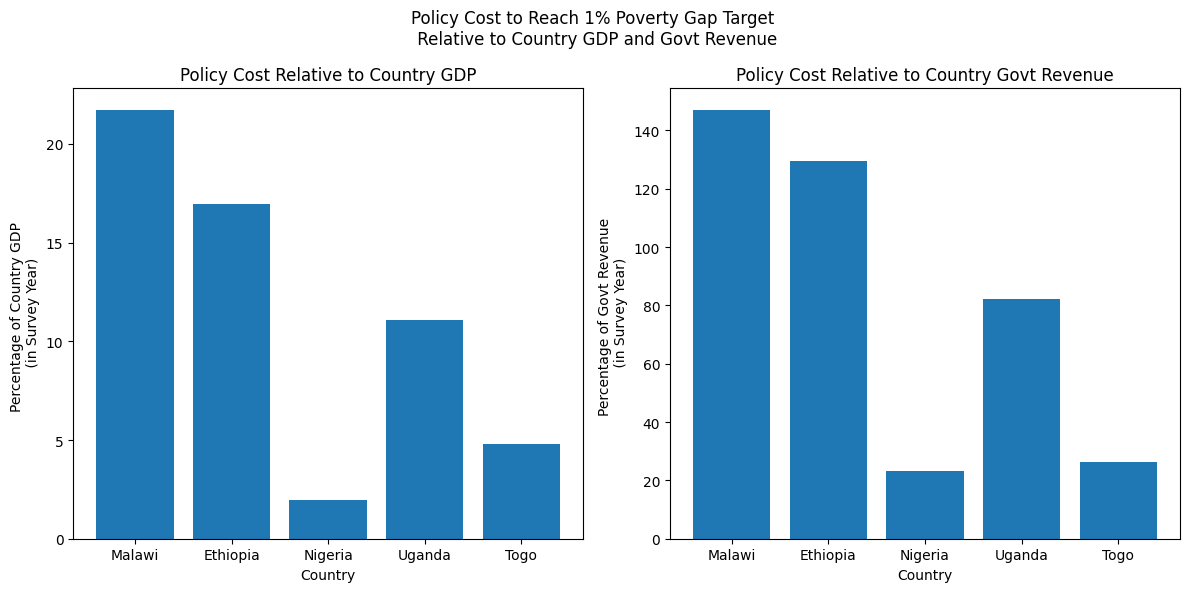

In [3]:
countries = ['malawi', 'ethiopia', 'nigeria', 'uganda', 'togo']
plot_bar_chart_policy_amt_as_percent_of_gdp(countries, 'continuous_gap', True, save_as='paper-figure-6_policy_cost_gdp')